## Exercícios 1 - 5

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv("data/FAOSTAT_data_12-5-2020 (1).csv")

In [5]:
data.head(3)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description
0,QC,Crops,9,Argentina,5419,Yield,515,Apples,2016,2016,hg/ha,223912,Fc,Calculated data
1,QC,Crops,9,Argentina,5419,Yield,515,Apples,2017,2017,hg/ha,235386,Fc,Calculated data
2,QC,Crops,9,Argentina,5419,Yield,515,Apples,2018,2018,hg/ha,213072,Fc,Calculated data


In [6]:
data.tail(2)

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value,Flag,Flag Description
64,QC,Crops,231,United States of America,5510,Production,388,Tomatoes,2017,2017,tonnes,11141862,NaN,Official data
65,QC,Crops,231,United States of America,5510,Production,388,Tomatoes,2018,2018,tonnes,12612139,NaN,Official data


In [9]:
data.columns

Index(['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element',
       'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag',
       'Flag Description'],
      dtype='str')

In [10]:
data.index

RangeIndex(start=0, stop=66, step=1)

In [11]:
data.shape

(66, 14)

In [13]:
data.dtypes

Domain Code           str
Domain                str
Area Code           int64
Area                  str
Element Code        int64
Element               str
Item Code           int64
Item                  str
Year Code           int64
Year                int64
Unit                  str
Value               int64
Flag                  str
Flag Description      str
dtype: object

In [14]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Domain Code       66 non-null     str  
 1   Domain            66 non-null     str  
 2   Area Code         66 non-null     int64
 3   Area              66 non-null     str  
 4   Element Code      66 non-null     int64
 5   Element           66 non-null     str  
 6   Item Code         66 non-null     int64
 7   Item              66 non-null     str  
 8   Year Code         66 non-null     int64
 9   Year              66 non-null     int64
 10  Unit              66 non-null     str  
 11  Value             66 non-null     int64
 12  Flag              43 non-null     str  
 13  Flag Description  66 non-null     str  
dtypes: int64(6), str(8)
memory usage: 7.3 KB


In [16]:
data['Area'].unique()

<StringArray>
['Argentina', 'Brazil', 'United States of America']
Length: 3, dtype: str

In [17]:
data['Element'].unique()

<StringArray>
['Yield', 'Production']
Length: 2, dtype: str

In [18]:
data['Item'].unique()

<StringArray>
['Apples', 'Bananas', 'Cherries', 'Tomatoes']
Length: 4, dtype: str

In [20]:
col = ['Domain Code', 'Domain', 'Area Code', 'Element Code', 'Item Code', 'Year Code', 'Flag', 'Flag Description']
data.drop(columns = col, inplace = True)

In [21]:
data

,Area,Element,Item,Year,Unit,Value
0,Argentina,Yield,Apples,2016,hg/ha,223912
1,Argentina,Yield,Apples,2017,hg/ha,235386
2,Argentina,Yield,Apples,2018,hg/ha,213072
3,Argentina,Production,Apples,2016,tonnes,458908
4,Argentina,Production,Apples,2017,tonnes,458908
...,...,...,...,...,...,...
61,United States of America,Yield,Tomatoes,2017,hg/ha,886625
62,United States of America,Yield,Tomatoes,2018,hg/ha,968079
63,United States of America,Production,Tomatoes,2016,tonnes,12877049
64,United States of America,Production,Tomatoes,2017,tonnes,11141862


In [22]:
def sigla (pais):
    if pais == 'Argentina':
        return 'AR'
    elif pais == 'United States of America':
        return 'USA'
    else:
        return 'BR'

In [23]:
data['Area'] = data['Area'].apply(sigla)

In [24]:
data['Value'] = data['Value'].astype(float)

In [27]:
data['Coutry/Commodity'] = data['Area']+' '+ data['Item']

In [28]:
data

,Area,Element,Item,Year,Unit,Value,Coutry/Commodity
0,AR,Yield,Apples,2016,hg/ha,223912.0,AR Apples
1,AR,Yield,Apples,2017,hg/ha,235386.0,AR Apples
2,AR,Yield,Apples,2018,hg/ha,213072.0,AR Apples
3,AR,Production,Apples,2016,tonnes,458908.0,AR Apples
4,AR,Production,Apples,2017,tonnes,458908.0,AR Apples
...,...,...,...,...,...,...,...
61,USA,Yield,Tomatoes,2017,hg/ha,886625.0,USA Tomatoes
62,USA,Yield,Tomatoes,2018,hg/ha,968079.0,USA Tomatoes
63,USA,Production,Tomatoes,2016,tonnes,12877049.0,USA Tomatoes
64,USA,Production,Tomatoes,2017,tonnes,11141862.0,USA Tomatoes


In [29]:
producao = data.groupby('Element').get_group('Production')

In [30]:
producao

,Area,Element,Item,Year,Unit,Value,Coutry/Commodity
3,AR,Production,Apples,2016,tonnes,458908.0,AR Apples
4,AR,Production,Apples,2017,tonnes,458908.0,AR Apples
5,AR,Production,Apples,2018,tonnes,510478.0,AR Apples
9,AR,Production,Bananas,2016,tonnes,174644.0,AR Bananas
10,AR,Production,Bananas,2017,tonnes,174615.0,AR Bananas
11,AR,Production,Bananas,2018,tonnes,174585.0,AR Bananas
15,AR,Production,Cherries,2016,tonnes,7207.0,AR Cherries
16,AR,Production,Cherries,2017,tonnes,7246.0,AR Cherries
17,AR,Production,Cherries,2018,tonnes,7285.0,AR Cherries
21,AR,Production,Tomatoes,2016,tonnes,658237.0,AR Tomatoes


In [31]:
produtividade = data.groupby('Element').get_group('Yield')

In [32]:
produtividade

,Area,Element,Item,Year,Unit,Value,Coutry/Commodity
0,AR,Yield,Apples,2016,hg/ha,223912.0,AR Apples
1,AR,Yield,Apples,2017,hg/ha,235386.0,AR Apples
2,AR,Yield,Apples,2018,hg/ha,213072.0,AR Apples
6,AR,Yield,Bananas,2016,hg/ha,209247.0,AR Bananas
7,AR,Yield,Bananas,2017,hg/ha,209343.0,AR Bananas
8,AR,Yield,Bananas,2018,hg/ha,209440.0,AR Bananas
12,AR,Yield,Cherries,2016,hg/ha,28417.0,AR Cherries
13,AR,Yield,Cherries,2017,hg/ha,30220.0,AR Cherries
14,AR,Yield,Cherries,2018,hg/ha,29790.0,AR Cherries
18,AR,Yield,Tomatoes,2016,hg/ha,393807.0,AR Tomatoes


In [34]:
producao = producao.pivot(index = 'Year', columns = 'Coutry/Commodity', values = 'Value')

In [35]:
producao

Coutry/Commodity,AR Apples,AR Bananas,AR Cherries,AR Tomatoes,BR Apples,BR Bananas,BR Tomatoes,USA Apples,USA Bananas,USA Cherries,USA Tomatoes
Year,,,,,,,,,,,
2016,458908.0,174644.0,7207.0,658237.0,1055383.0,6625211.0,4166789.0,5214040.0,3387.0,315454.0,12877049.0
2017,458908.0,174615.0,7246.0,655861.0,1307642.0,6584967.0,4225414.0,5240670.0,3992.0,398140.0,11141862.0
2018,510478.0,174585.0,7285.0,653485.0,1195007.0,6752171.0,4110242.0,4652500.0,4274.0,312430.0,12612139.0


In [36]:
produtividade = produtividade.pivot(index = 'Year', columns = 'Coutry/Commodity', values = 'Value')

In [38]:
produtividade

Coutry/Commodity,AR Apples,AR Bananas,AR Cherries,AR Tomatoes,BR Apples,BR Bananas,BR Tomatoes,USA Apples,USA Bananas,USA Cherries,USA Tomatoes
Year,,,,,,,,,,,
2016,223912.0,209247.0,28417.0,393807.0,308465.0,142855.0,651112.0,391856.0,115204.0,86902.0,911398.0
2017,235386.0,209343.0,30220.0,394319.0,392355.0,142728.0,688145.0,394569.0,158413.0,108960.0,886625.0
2018,213072.0,209440.0,29790.0,394832.0,361805.0,150287.0,719404.0,394802.0,163756.0,90828.0,968079.0


In [39]:
df_mod = pd.concat([producao, produtividade], axis = 0, keys = ['Production', 'Yield'])

In [40]:
df_mod

Coutry/Commodity  AR Apples  AR Bananas  AR Cherries  AR Tomatoes  BR Apples  \
           Year                                                                
Production 2016    458908.0    174644.0       7207.0     658237.0  1055383.0   
           2017    458908.0    174615.0       7246.0     655861.0  1307642.0   
           2018    510478.0    174585.0       7285.0     653485.0  1195007.0   
Yield      2016    223912.0    209247.0      28417.0     393807.0   308465.0   
           2017    235386.0    209343.0      30220.0     394319.0   392355.0   
           2018    213072.0    209440.0      29790.0     394832.0   361805.0   

Coutry/Commodity  BR Bananas  BR Tomatoes  USA Apples  USA Bananas  \
           Year                                                      
Production 2016    6625211.0    4166789.0   5214040.0       3387.0   
           2017    6584967.0    4225414.0   5240670.0       3992.0   
           2018    6752171.0    4110242.0   4652500.0       4274.0   
Yield      2016     142855.0     651112.0    391856.0     115204.0   
           2017     142728.0     688145.0    394569.0     158413.0   
           2018     150287.0     719404.0    394802.0     163756.0   

Coutry/Commodity  USA Cherries  USA Tomatoes  
           Year                               
Production 2016       315454.0    12877049.0  
           2017       398140.0    11141862.0  
           2018       312430.0    12612139.0  
Yield      2016        86902.0      911398.0  
           2017       108960.0      886625.0  
           2018        90828.0      968079.0

## Exercícios 6 - 12

In [55]:
df = pd.read_csv("data\kc_house_data.csv")

In [56]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [57]:
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [58]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [59]:
df.index

RangeIndex(start=0, stop=21613, step=1)

In [60]:
df.shape

(21613, 21)

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [62]:
df.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [63]:
col = ['id','date','zipcode','lat','long']
df = df.drop(columns=col)

In [64]:
df

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,1530,1509
21609,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,1830,7200
21610,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,1020,2007
21611,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,1410,1287


In [65]:
df.isna().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [66]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,6210.000000,871200.000000


In [68]:
corr = df.corr()

In [69]:
cov = df.cov()

In [70]:
cov

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
price,1.347824e+11,105286.276362,148481.495749,2.367154e+08,1.363437e+09,50908.003884,8460.643388,111772.969096,8687.030331,288026.499738,1.841014e+08,5.261406e+07,582448.362866,1.864486e+07,1.472964e+08,8.264591e+08
bedrooms,1.052863e+05,0.865015,0.369527,4.925960e+02,1.221324e+03,0.088104,-0.000530,0.056684,0.017232,0.390254,3.678361e+02,1.247599e+02,4.212004,7.038678e+00,2.496518e+02,7.426446e+02
bathrooms,1.484815e+05,0.369527,0.593151,5.338120e+02,2.798944e+03,0.208211,0.004247,0.110800,-0.062638,0.602005,4.370876e+02,9.672443e+01,11.447333,1.569654e+01,3.001611e+02,1.833182e+03
sqft_living,2.367154e+08,492.596040,533.811988,8.435337e+05,6.574684e+06,175.540402,8.249461,200.314304,-35.114601,823.407664,6.666978e+05,1.768358e+05,8580.237559,2.042442e+04,4.761601e+05,4.596302e+06
sqft_lot,1.363437e+09,1221.324216,2798.943628,6.574684e+06,1.715659e+09,-116.328567,77.418670,2371.393311,-241.461641,5531.996968,6.294462e+06,2.802218e+05,64580.849602,1.271708e+05,4.105319e+06,8.126540e+08
floors,5.090800e+04,0.088104,0.208211,1.755404e+02,-1.163286e+02,0.291588,0.001107,0.012184,-0.092686,0.290824,2.342603e+02,-5.871985e+01,7.761250,1.374814e+00,1.035866e+02,-1.661524e+02
waterfront,8.460643e+03,-0.000530,0.004247,8.249461e+00,7.741867e+01,0.001107,0.007485,0.026643,0.000938,0.008418,5.163720e+00,3.085741e+00,-0.066483,3.227949e+00,5.127103e+00,7.252979e+01
view,1.117730e+05,0.056684,0.110800,2.003143e+02,2.371393e+03,0.012184,0.026643,0.587243,0.022934,0.226383,1.063870e+02,9.392727e+01,-1.202897,3.198718e+01,1.472943e+02,1.518526e+03
condition,8.687030e+03,0.017232,-0.062638,-3.511460e+01,-2.414616e+02,-0.092686,0.000938,0.022934,0.423467,-0.110664,-8.525727e+01,5.014267e+01,-6.908312,-1.584488e+01,-4.140089e+01,-6.050935e+01
grade,2.880265e+05,0.390254,0.602005,8.234077e+02,5.531997e+03,0.290824,0.008418,0.226383,-0.110664,1.381703,7.358054e+02,8.760226e+01,15.432403,6.805809e+00,5.745907e+02,3.827254e+03


<Axes: >

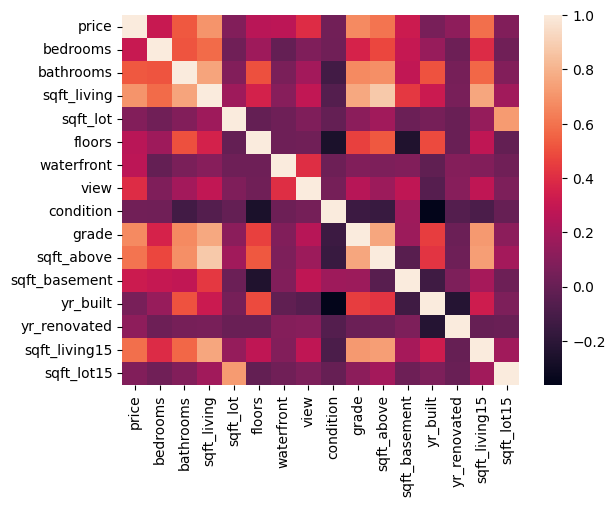

In [71]:
sns.heatmap(corr)

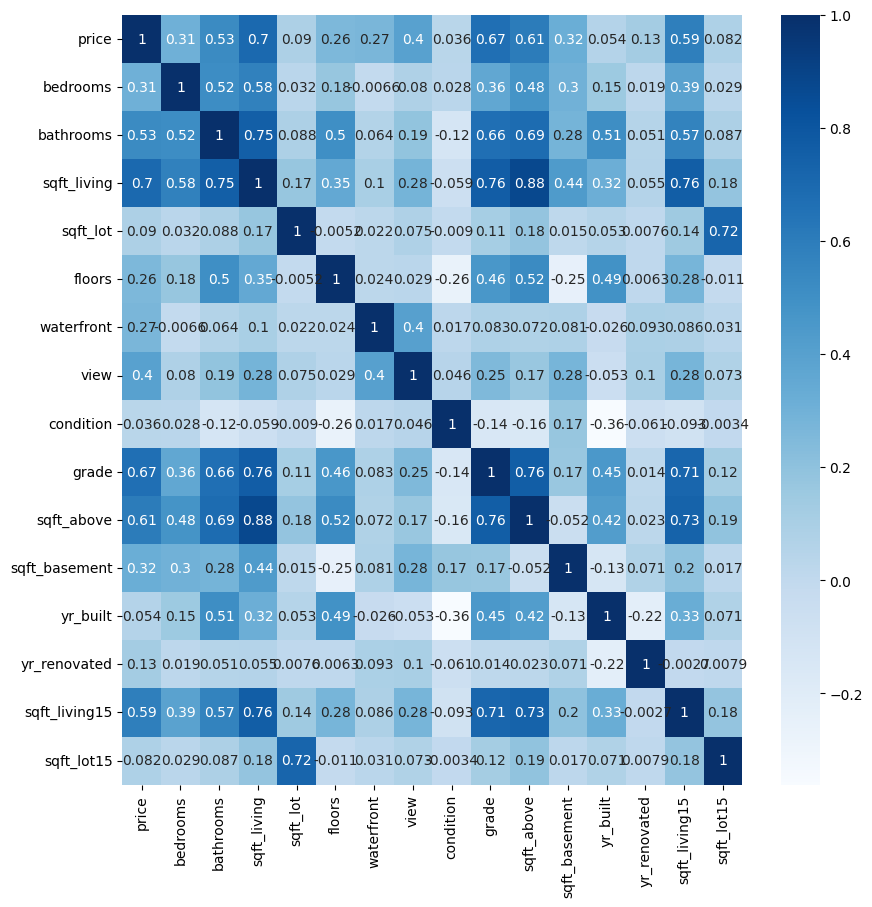

In [72]:
plt.figure(figsize = (10, 10))
sns.heatmap(corr, cmap = 'Blues', annot = True);

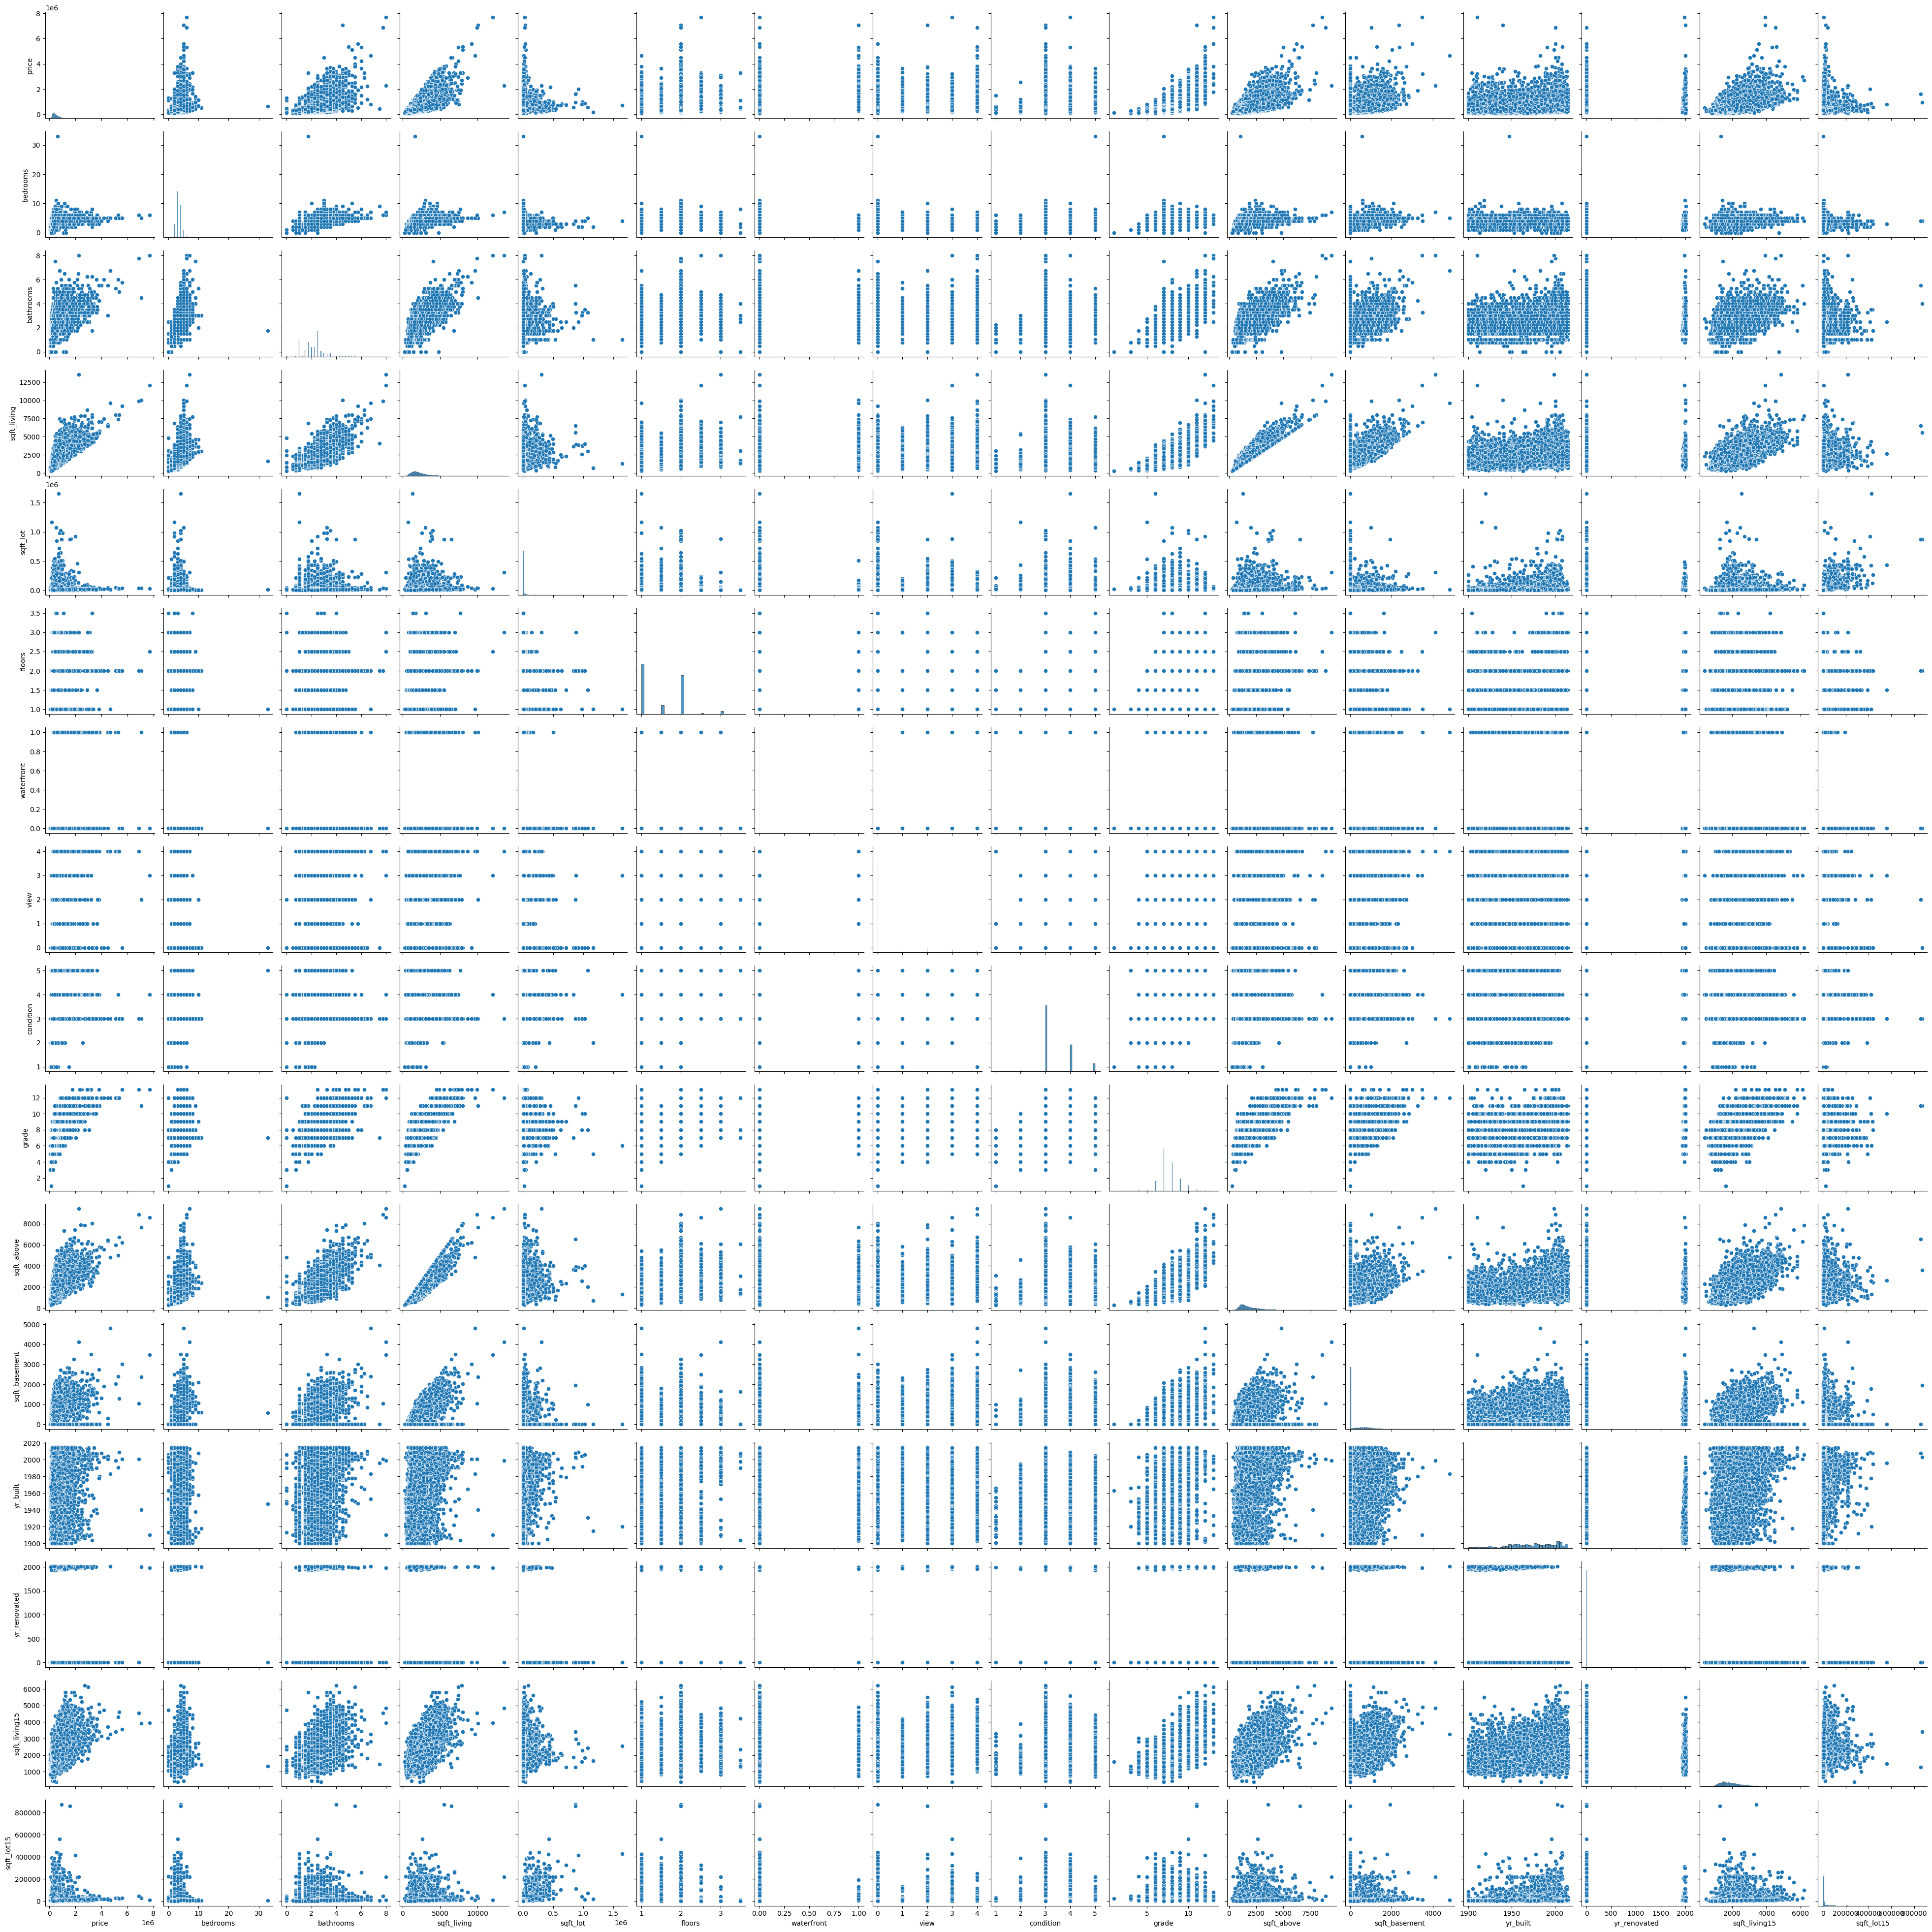

In [74]:
sns.pairplot(df)

In [75]:
y = df['price']
x = df.drop('price', axis = 1)

In [76]:
y

0        221900.0
1        538000.0
2        180000.0
3        604000.0
4        510000.0
           ...   
21608    360000.0
21609    400000.0
21610    402101.0
21611    400000.0
21612    325000.0
Name: price, Length: 21613, dtype: float64

In [77]:
x

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,1530,1509
21609,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,1830,7200
21610,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,1020,2007
21611,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,1410,1287


In [78]:
from sklearn.model_selection import train_test_split

In [79]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.3, random_state = 33)


In [80]:
x_treino.shape

(15129, 15)

In [81]:
y_treino.shape

(15129,)

In [82]:
x_teste.shape

(6484, 15)

In [84]:
y_teste.shape

(6484,)

In [85]:
from sklearn.linear_model import LinearRegression

In [86]:
modelo = LinearRegression()
modelo.fit(x_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
modelo.score(x_teste, y_teste)

0.6496675233034952

## Exercicios 13 - 23

In [138]:
dataset = pd.read_csv("data\StudentsPerformance.csv")

In [139]:
dataset.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [140]:
dataset.tail(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [141]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [142]:
dataset.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [143]:
dataset.index

RangeIndex(start=0, stop=1000, step=1)

In [144]:
dataset.shape

(1000, 8)

In [145]:
dataset.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [146]:
dataset.rename(columns = lambda coluna:'_'.join(coluna.title().split()), inplace = True)

In [147]:
dataset['Gender'].value_counts()

Gender
female    518
male      482
Name: count, dtype: int64

In [148]:
for coluna,valor in dataset.items():
    print(coluna)
    print()
    print(valor.value_counts())
    print()

Gender

Gender
female    518
male      482
Name: count, dtype: int64

Race/Ethnicity

Race/Ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Parental_Level_Of_Education

Parental_Level_Of_Education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Lunch

Lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Test_Preparation_Course

Test_Preparation_Course
none         642
completed    358
Name: count, dtype: int64

Math_Score

Math_Score
65    36
62    35
69    32
59    32
73    27
      ..
24     1
26     1
19     1
23     1
8      1
Name: count, Length: 81, dtype: int64

Reading_Score

Reading_Score
72    34
74    33
64    32
73    30
67    30
      ..
17     1
26     1
28     1
23     1
40     1
Name: count, Length: 72, dtype: int64

Writing_Score

Writing_Score
74    35
7

In [149]:
provas = dataset.columns[-3:].to_list()

In [150]:
provas

['Math_Score', 'Reading_Score', 'Writing_Score']

In [152]:
(dataset.isna().sum()/df.shape[0])*100

Gender                         0.0
Race/Ethnicity                 0.0
Parental_Level_Of_Education    0.0
Lunch                          0.0
Test_Preparation_Course        0.0
Math_Score                     0.0
Reading_Score                  0.0
Writing_Score                  0.0
dtype: float64

In [153]:
dataset.describe()

,Math_Score,Reading_Score,Writing_Score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [155]:
genero = dataset.groupby('Gender')

In [156]:
genero

In [157]:
metricas = [np.mean, np.median, np.var, np.std]

In [158]:
genero[provas].agg(metricas).T

Gender                    female        male
Math_Score    mean     63.633205   68.728216
              median   65.000000   69.000000
              var     239.521832  205.675096
              std      15.476493   14.341377
Reading_Score mean     72.608108   65.473029
              median   73.000000   66.000000
              var     206.334838  193.693256
              std      14.364360   13.917372
Writing_Score mean     72.467181   63.311203
              median   74.000000   64.000000
              var     219.943904  198.786970
              std      14.830506   14.099183

In [160]:
gender_preparation = (dataset.groupby(['Gender', 'Test_Preparation_Course']))

In [162]:
gender_preparation = (dataset.groupby(['Gender', 'Test_Preparation_Course'])
                      [provas].agg(metricas)).T

In [163]:
gender_preparation

Gender                       female                    male            
Test_Preparation_Course   completed        none   completed        none
Math_Score    mean        67.195652   61.670659   72.339080   66.688312
              median      67.000000   62.000000   73.000000   67.000000
              var        201.798677  249.460397  201.097668  196.734019
              std         14.205586   15.794315   14.180891   14.026190
Reading_Score mean        77.375000   69.982036   70.212644   62.795455
              median      78.000000   71.000000   71.000000   63.000000
              var        160.299592  212.281114  185.753633  178.318551
              std         12.660948   14.569870   13.629146   13.353597
Writing_Score mean        78.793478   68.982036   69.793103   59.649351
              median      79.000000   70.000000   70.000000   60.000000
              var        149.022566  224.820037  167.830757  179.130292
              std         12.207480   14.994000   12.954951   13.383957

In [165]:
grupo3 = (dataset.groupby(['Race/Ethnicity', 'Parental_Level_Of_Education'])
                      [provas].agg(metricas)).T

In [166]:
grupo3

Race/Ethnicity                         group A                                \
Parental_Level_Of_Education associate's degree bachelor's degree high school   
Math_Score    mean                   61.000000         67.166667   60.444444   
              median                 62.500000         65.000000   60.000000   
              var                   273.714286        205.972222  124.691358   
              std                    16.544313         14.351732   11.166528   
Reading_Score mean                   67.071429         68.083333   62.888889   
              median                 61.000000         65.500000   65.000000   
              var                   202.209184        157.909722  186.098765   
              std                    14.220028         12.566214   13.641802   
Writing_Score mean                   63.571429         68.333333   60.500000   
              median                 58.500000         64.500000   62.500000   
              var                   231.102041        138.222222  177.361111   
              std                    15.202041         11.756795   13.317699   

Race/Ethnicity                                                             \
Parental_Level_Of_Education master's degree some college some high school   
Math_Score    mean                57.666667    63.888889        58.916667   
              median              50.000000    61.000000        59.000000   
              var                117.555556   239.098765       193.409722   
              std                 10.842304    15.462819        13.907182   
Reading_Score mean                64.666667    65.777778        62.083333   
              median              67.000000    66.000000        62.000000   
              var                 76.222222   298.061728       297.159722   
              std                  8.730534    17.264464        17.238321   
Writing_Score mean                67.666667    65.000000        58.583333   
              median              72.000000    67.000000        55.500000   
              var                 46.888889   288.888889       273.909722   
              std                  6.847546    16.996732        16.550218   

Race/Ethnicity                         group B                                \
Parental_Level_Of_Education associate's degree bachelor's degree high school   
Math_Score    mean                   66.097561         69.300000   59.791667   
              median                 65.000000         66.500000   62.000000   
              var                   215.649018        146.110000  239.248264   
              std                    14.684993         12.087597   15.467652   
Reading_Score mean                   69.585366         72.950000   63.458333   
              median                 70.000000         73.000000   64.500000   
              var                   200.047591        160.847500  261.831597   
              std                    14.143818         12.682567   16.181211   
Writing_Score mean                   68.243902         71.650000   61.250000   
              median                 68.000000         75.000000   62.500000   
              var                   187.257585        185.327500  266.645833   
              std                    13.684209         13.613504   16.329294   

Race/Ethnicity                               ...     group D                  \
Parental_Level_Of_Education master's degree  ... high school master's degree   
Math_Score    mean                67.166667  ...   62.863636       72.521739   
              median              67.500000  ...   64.500000       77.000000   
              var                226.472222  ...  160.663223      223.553875   
              std                 15.048994  ...   12.675300       14.951718   
Reading_Score mean                80.166667  ...   64.409091       77.173913   
              median              83.000000  ...   65.000000       80.000000   
              var                243.13

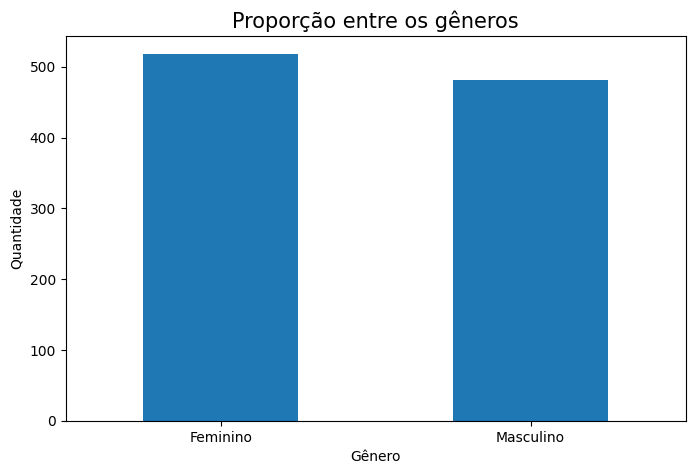

In [ ]:
dataset['Gender'].value_counts().plot(kind = 'bar', figsize = (8, 5))
plt.title('Proporção entre os gêneros', fontsize= 15)
plt.xlabel('Gender')
plt.xticks([0, 1], ['Feminino', 'Masculino'], rotation = 0)
plt.ylabel('Quantidade')
plt.xlabel('Gênero')
plt.show()

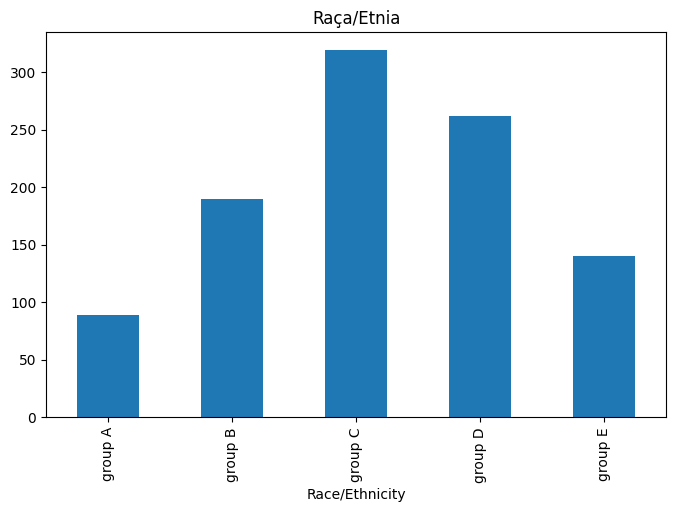

In [170]:
plt.figure(figsize = (8, 5))
dataset['Race/Ethnicity'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Raça/Etnia');

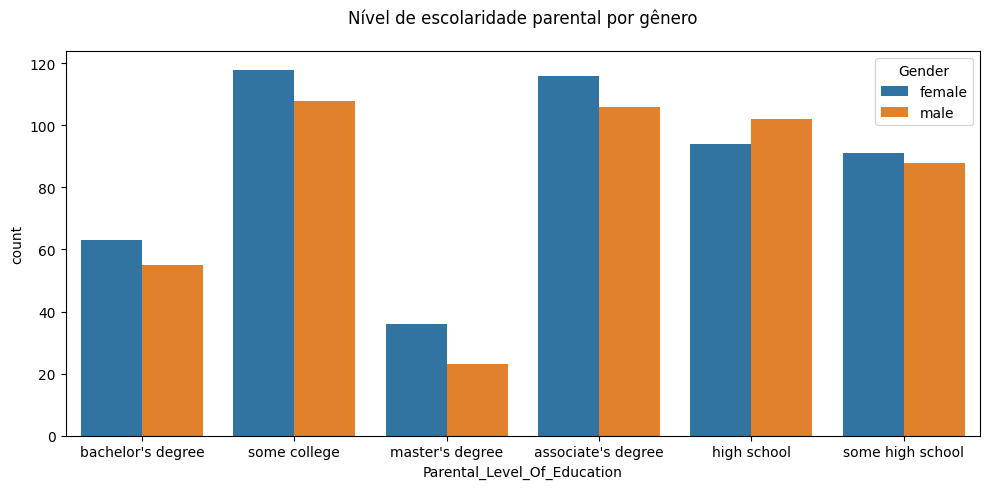

In [171]:
plt.figure(figsize = (10, 5))
sns.countplot(
    data = dataset,
    x = 'Parental_Level_Of_Education',
    hue= 'Gender'
)
plt.title('Nível de escolaridade parental por gênero', pad = 20)
plt.tight_layout();

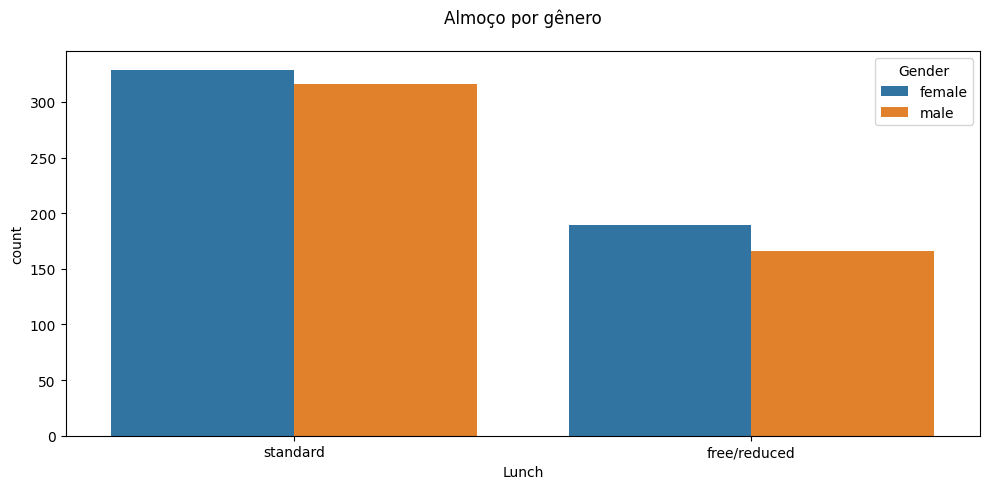

In [172]:
plt.figure(figsize = (10, 5))
sns.countplot(
    data = dataset,
    x = 'Lunch',
    hue= 'Gender'
)
plt.title('Almoço por gênero', pad = 20)
plt.tight_layout();

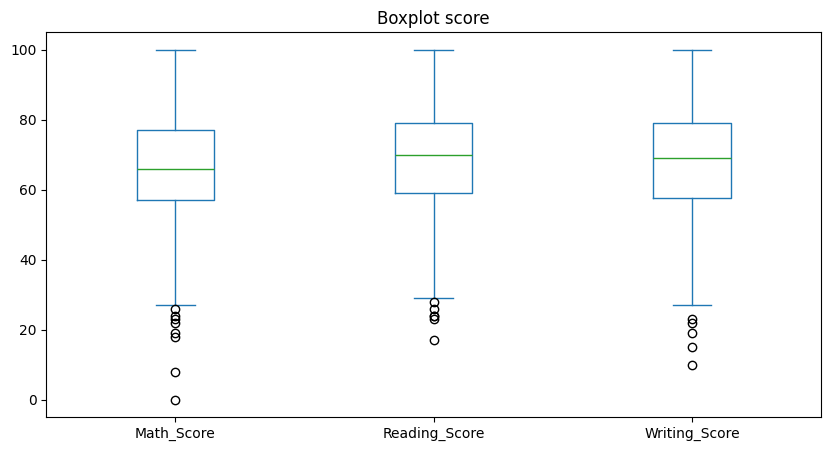

In [173]:
dataset[provas].plot(kind = 'box', figsize = (10,5))
plt.title('Boxplot score');

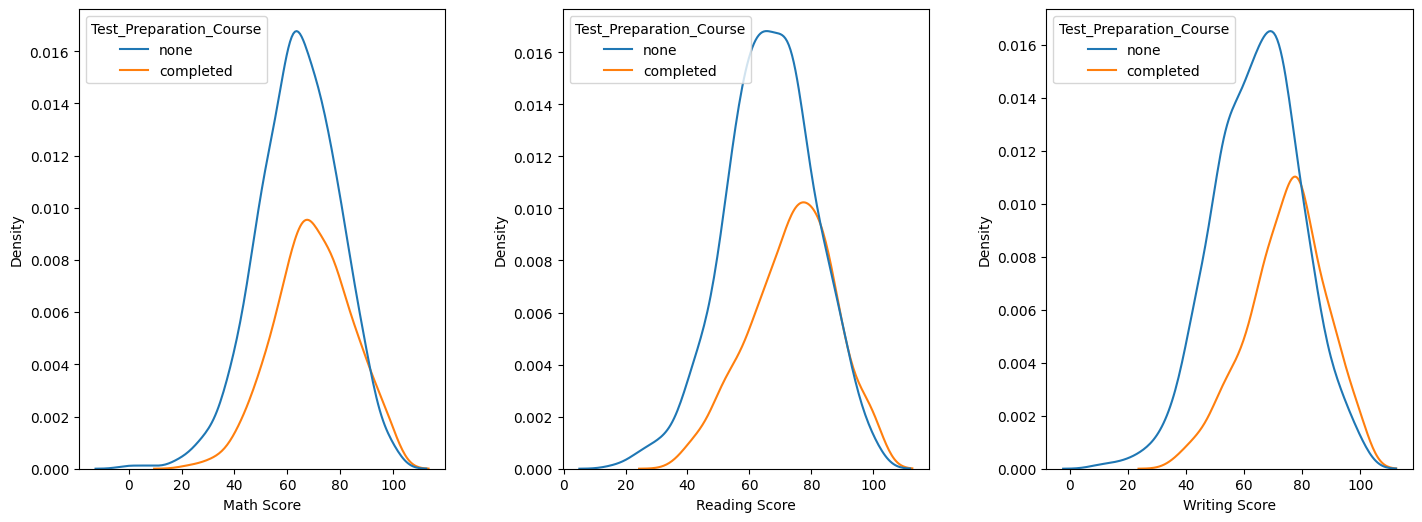

In [175]:
fig, (ax0, ax1, ax2) = plt.subplots(ncols = 3, figsize = (15,6))

sns.kdeplot(data = dataset, x = 'Math_Score', hue = 'Test_Preparation_Course', ax = ax0)
ax0.set_xlabel('Math Score')

sns.kdeplot(data = dataset, x = 'Reading_Score', hue = 'Test_Preparation_Course', ax = ax1)
ax1.set_xlabel('Reading Score')

sns.kdeplot(data = dataset, x = 'Writing_Score', hue = 'Test_Preparation_Course', ax = ax2)
ax2.set_xlabel('Writing Score')

plt.tight_layout(pad = 3.5)

In [178]:
corr = dataset.corr(numeric_only=True)

In [179]:
cov = dataset.cov(numeric_only=True)

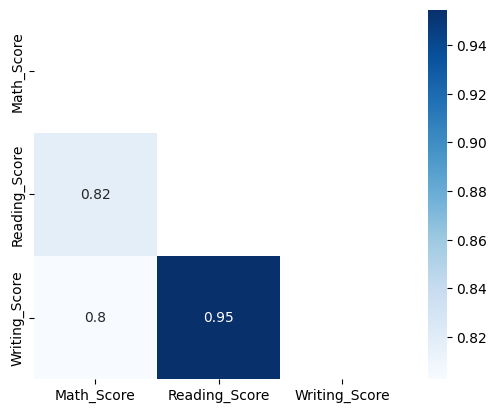

In [180]:
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr,
    annot = True,
    mask = mask,
    square = True,
    cmap = 'Blues');

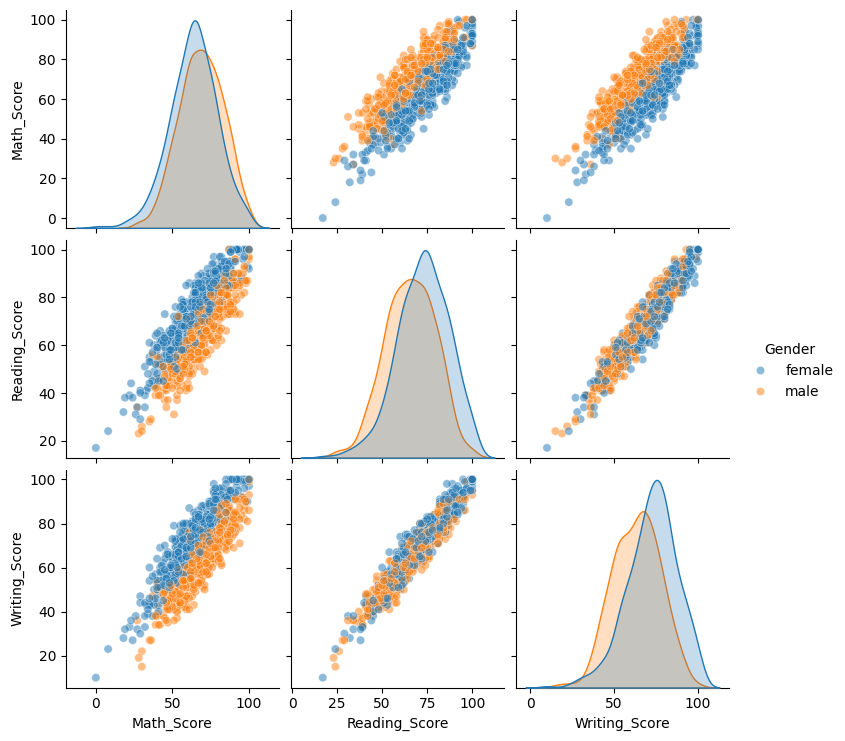

In [181]:
sns.pairplot(dataset, hue = 'Gender', plot_kws = {'alpha':0.5});


## Exercicios 24 - 33

In [183]:
df = pd.read_csv("data\Salary_Data.csv")

In [184]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [185]:
df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [186]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='str')

In [187]:
df.index

RangeIndex(start=0, stop=30, step=1)

In [188]:
df.shape

(30, 2)

In [189]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [190]:
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [193]:
df.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [194]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [195]:
coor = df.corr()

In [196]:
coor

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [197]:
cov = df.cov()

In [198]:
cov

,YearsExperience,Salary
YearsExperience,8.053609,7.610630e+04
Salary,76106.303448,7.515510e+08


<Axes: >

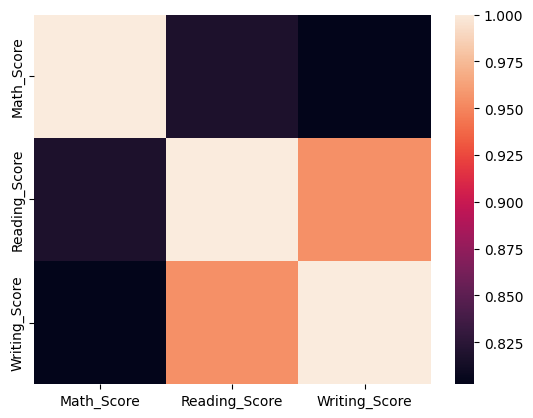

In [199]:
sns.heatmap(corr)

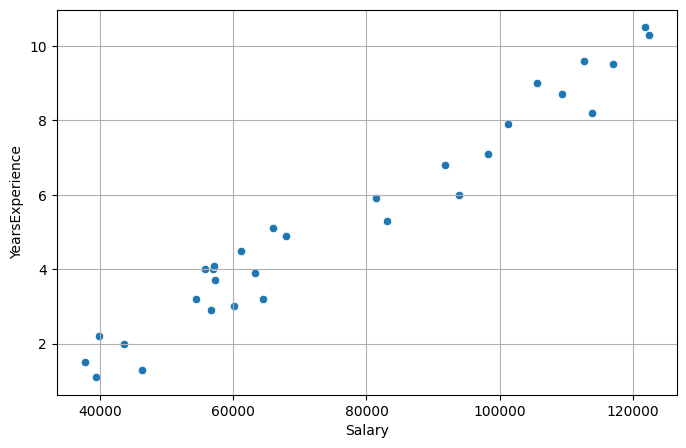

In [200]:
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'Salary', y = 'YearsExperience')
plt.grid();

<Axes: >

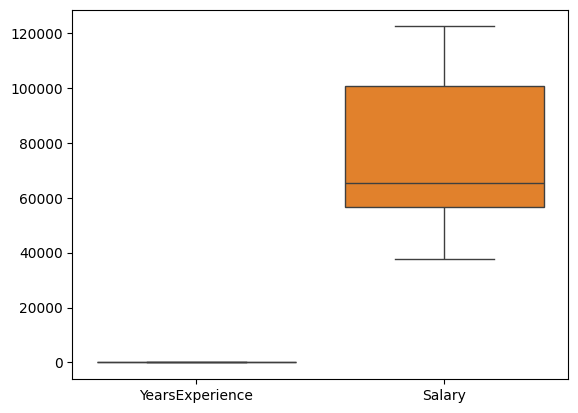

In [201]:
sns.boxplot(df)

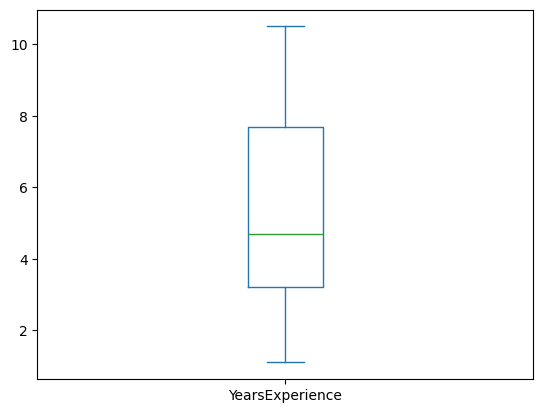

In [202]:
df['YearsExperience'].plot(kind = 'box');

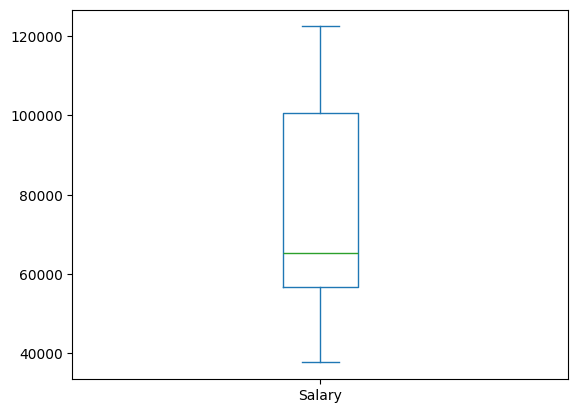

In [203]:
df['Salary'].plot(kind = 'box');


In [204]:
sal = df['Salary']

In [205]:
sal

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [206]:
x = df['YearsExperience'].values.reshape(-1, 1)
y = df['Salary'].values.reshape(-1, 1)

In [207]:
from sklearn.model_selection import train_test_split

In [208]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.3, random_state = 7)

In [209]:
x_treino.shape,y_treino.shape

((21, 1), (21, 1))

In [210]:
y_teste.shape, y_teste.shape

((9, 1), (9, 1))

In [211]:
from sklearn.linear_model import LinearRegression

In [212]:
modelo = LinearRegression()
modelo.fit(x_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [213]:
print(f'Coeficiente de determinação (R^2): {modelo.score(x_teste, y_teste)}')

Coeficiente de determinação (R^2): 0.958816457461513


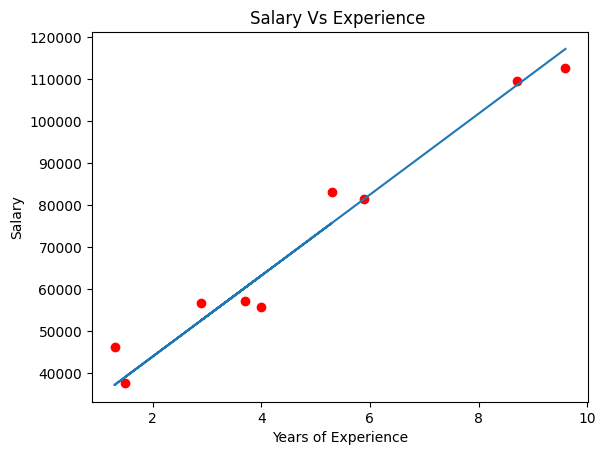

In [214]:
plt.scatter(x_teste, y_teste, c= "red")
plt.plot(x_teste, modelo.predict(x_teste))
plt.title("Salary Vs Experience ")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [215]:
import statsmodels.api as sm

In [216]:
Y = df['Salary']
X = df['YearsExperience']
X = sm.add_constant(X)
modelo_OLS = sm.OLS(Y, X)
resultados = modelo_OLS.fit()
resultados.params

const              25792.200199
YearsExperience     9449.962321
dtype: float64

In [217]:
resultados.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.14e-20
Time:                        23:07:11   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            2.579e+04   2273.053     11.347      0.000    2.11e+04    3.04e+04
YearsExperience  9449.9623    378.755     24.950      0.000    8674.119    1.02e+04
==============================================================================
Omnibus:                        2.140   Durbin-Watson:                   1.648
Prob(Omnibus):                  0.343   Jarque-Bera (JB):                1.569
Skew:                           0.363   Prob(JB):                        0.456
Kurtosis:                       2.147   Cond. No.                         13.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

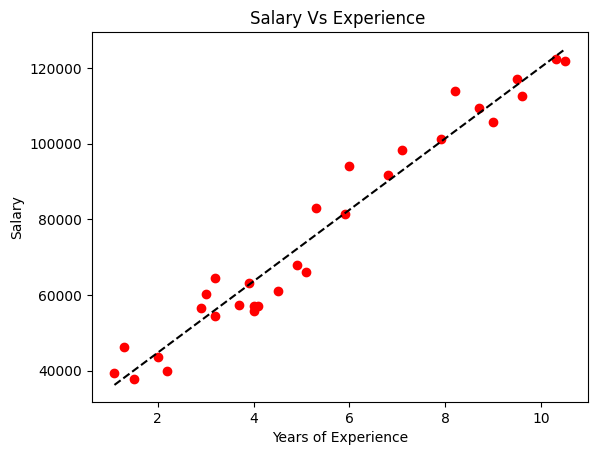

In [218]:
Y = [25792.20+9449.96*i for i in df['YearsExperience']]
plt.scatter(x = df['YearsExperience'], y = df['Salary'], c = 'r')
plt.plot(df['YearsExperience'], Y, color = 'k', ls = '--')
plt.title("Salary Vs Experience ")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()